In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
from model.resnet_cifar10_manual import resnet20
import matplotlib.pyplot as plt
import numpy as np
import timm
import detectors

device = ("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


Using device: cuda


In [2]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
test_dataset = datasets.CIFAR10(root="./datasets", train=False, download=True,transform=test_transform)
test_dataset_01 = datasets.CIFAR10(root="./datasets", train=False, download=True)

image_01, label_01 = test_dataset[0]
image_02, label_02 = test_dataset[42]


In [3]:
label_02

5

In [4]:
pruned1_4resnet20_path = torch.load("./Pruned_models/resnet20_cifar10_SNOWS_1:4_k=40_model.pth", map_location=device)
pruned2_4resnet20_path = torch.load("./Pruned_models/resnet20_cifar10_SNOWS_2:4_k=40_model.pth", map_location=device)
pruned3_50_resnet20_path = torch.load("./Pruned_models/resnet20_cifar10_SNOWS_0.5_0.7_model.pth", map_location=device)


In [5]:

pruned1_4resnet20 = resnet20()
pruned2_4resnet20 = resnet20()
pruned3_50_resnet20 = resnet20()

pruned1_4resnet20.load_state_dict(pruned1_4resnet20_path)
pruned2_4resnet20.load_state_dict(pruned2_4resnet20_path)
pruned3_50_resnet20.load_state_dict(pruned3_50_resnet20_path)

pruned1_4resnet20.eval()
pruned2_4resnet20.eval()
pruned3_50_resnet20.eval()


ResNetCifar(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [6]:
original_resnet20_dict = torch.load('./checkpoints/resnet20_cifar10.pt', map_location=device)
original_resnet20 = resnet20()

original_resnet20.load_state_dict(original_resnet20_dict)
original_resnet20.eval()

ResNetCifar(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [7]:
image_01 = image_01.unsqueeze(0).to(device)


In [8]:
original_resnet20.to(device)
pruned1_4resnet20.to(device)
pruned2_4resnet20.to(device)
pruned3_50_resnet20.to(device)

with torch.no_grad():
    output_original = original_resnet20(image_01)
    output1_4 = pruned1_4resnet20(image_01)
    output2_4 = pruned2_4resnet20(image_01)
    output_50 = pruned3_50_resnet20(image_01)

# predicted_probabilities = torch.nn.functional.softmax(output)
output_class_orig = torch.argmax(output_original, dim=1).item()
output_class_1_4 = torch.argmax(output1_4, dim=1).item()
output_class_2_4 = torch.argmax(output2_4, dim=1).item()
output_class_50 = torch.argmax(output_50, dim=1).item()

output_class_orig_probs = F.softmax(output_original, dim = 1)
output_class_1_4_probs = F.softmax(output1_4, dim=1)
output_class_2_4_probs = F.softmax(output2_4, dim=1)
output_class_50_probs = F.softmax(output_50, dim=1)

In [9]:
image, label = test_dataset_01[0]

Text(0.5, 1.0, 'Classification using \n 2:4 pruned ResNet20 \n cat(1.0)')

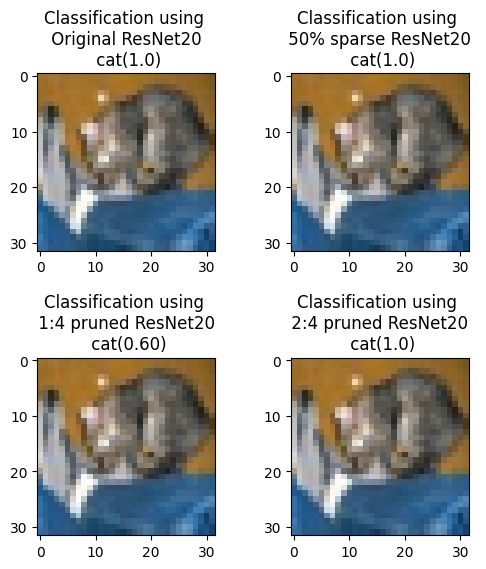

In [10]:
fig, axes = plt.subplots(2, 2, figsize = (6, 6))
# original_img = image.permute(1, 2, 0)
plt.subplots_adjust(hspace=0.6)
axes[0, 0].imshow(image)
axes[0, 0].set_title(f"Classification using \n Original ResNet20 \n {test_dataset.classes[output_class_orig]}({output_class_orig_probs[0, output_class_orig].item()})")

axes[0, 1].imshow(image)
axes[0, 1].set_title(f"Classification using \n 50% sparse ResNet20 \n {test_dataset.classes[output_class_50]}({output_class_50_probs[0, output_class_50].item()})")


axes[1, 0].imshow(image)
axes[1, 0].set_title(f"Classification using \n 1:4 pruned ResNet20 \n {test_dataset.classes[output_class_1_4]}({output_class_1_4_probs[0, output_class_1_4].item():.2f})")


axes[1, 1].imshow(image)
axes[1, 1].set_title(f"Classification using \n 2:4 pruned ResNet20 \n {test_dataset.classes[output_class_2_4]}({output_class_2_4_probs[0, output_class_2_4].item()})")


In [11]:
original_resnet50 = timm.create_model("resnet50_cifar10", pretrained=True)
original_resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [12]:
image, label = test_dataset_01[42]

In [13]:
pruned1_4resnet50_path = torch.load("./Pruned_models/resnet50_cifar10_SNOWS_1:4_k=40_model.pth", map_location=device)
pruned2_4resnet50_path = torch.load("./Pruned_models/resnet50_cifar10_SNOWS_2:4_k=40_model.pth", map_location=device)
pruned60_resnet50_path = torch.load("./Pruned_models/resnet50_cifar10_SNOWS_0.6_0.8_model.pth", map_location=device)

In [14]:
pruned2_4resnet50 = timm.create_model("resnet50_cifar10", pretrained=False)
pruned1_4resnet50 = timm.create_model("resnet50_cifar10", pretrained=False)
pruned60_resnet50 = timm.create_model("resnet50_cifar10", pretrained=False)

pruned1_4resnet50.load_state_dict(pruned1_4resnet50_path)
pruned2_4resnet50.load_state_dict(pruned2_4resnet50_path)
pruned60_resnet50.load_state_dict(pruned60_resnet50_path)

pruned1_4resnet50.eval()
pruned2_4resnet50.eval()
pruned60_resnet50.eval()



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [15]:
original_resnet50.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [16]:
image_02 = image_02.unsqueeze(0).to(device)

In [17]:
test_dataset.classes[label_02]

'dog'

In [18]:
original_resnet50.to(device)
pruned1_4resnet50.to(device)
pruned2_4resnet50.to(device)
pruned60_resnet50.to(device)

with torch.no_grad():
    output_original = original_resnet50(image_02)
    output1_4 = pruned1_4resnet50(image_02)
    output2_4 = pruned2_4resnet50(image_02)
    output_60 = pruned60_resnet50(image_02)

output_class_dense = torch.argmax(output_original, dim=1).item()
output_class_1_4 = torch.argmax(output1_4, dim=1).item()
output_class_2_4 = torch.argmax(output2_4, dim=1).item()
output_class_60 = torch.argmax(output_60, dim=1).item()

output_class_orig_probs = F.softmax(output_original, dim = 1)
output_class_1_4_probs = F.softmax(output1_4, dim=1)
output_class_2_4_probs = F.softmax(output2_4, dim=1)
output_class60_probs = F.softmax(output_60, dim=1)


In [19]:
output_class_dense

5

Text(0.5, 1.0, 'Classification using \n 2:4 pruned ResNet50 \n dog(1.00)')

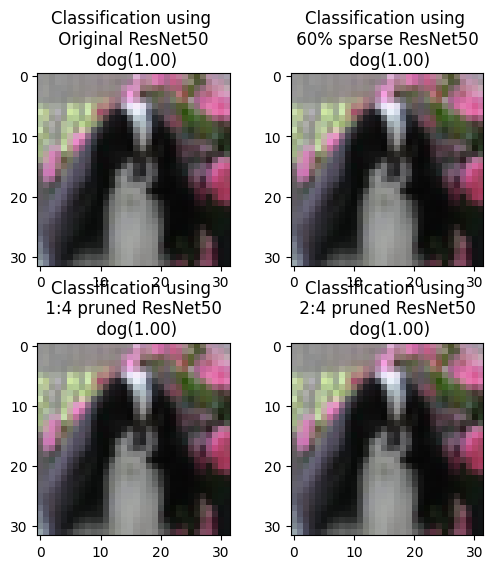

In [20]:
fig, axes = plt.subplots(2, 2, figsize = (6, 6))
# original_img = image.permute(1, 2, 0)
plt.subplots_adjust(hspace=0.4)
axes[0, 0].imshow(image)
axes[0, 0].set_title(f"Classification using \n Original ResNet50 \n {test_dataset.classes[output_class_dense]}({output_class_orig_probs[0, output_class_dense].item():.2f})")

axes[0, 1].imshow(image)
axes[0, 1].set_title(f"Classification using \n 60% sparse ResNet50 \n {test_dataset.classes[output_class_60]}({output_class60_probs[0, output_class_60].item():.2f})")


axes[1, 0].imshow(image)
axes[1, 0].set_title(f"Classification using \n 1:4 pruned ResNet50 \n {test_dataset.classes[output_class_1_4]}({output_class_1_4_probs[0, output_class_1_4].item():.2f})")


axes[1, 1].imshow(image)
axes[1, 1].set_title(f"Classification using \n 2:4 pruned ResNet50 \n {test_dataset.classes[output_class_2_4]}({output_class_2_4_probs[0, output_class_2_4].item():.2f})")


In [21]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
test_dataset_c100 = datasets.CIFAR100(root="./datasets", train=False, download=True,transform=test_transform)
test_dataset_unnorm_c100 = datasets.CIFAR100(root="./datasets", train=False, download=True)


In [22]:
image_03, label_03 = test_dataset_c100[4]

In [23]:
image, label = test_dataset_unnorm_c100[4]

In [24]:
pruned1_4resnet50c100_path = torch.load("./Pruned_models/resnet50_cifar100_SNOWS_1:4_k=40_model.pth", map_location=device)
pruned2_4resnet50c100_path = torch.load("./Pruned_models/resnet50_cifar100_SNOWS_2:4_k=40_model.pth", map_location=device)
pruned3_50resnet50c100_path = torch.load("./Pruned_models/resnet50_cifar100_SNOWS_0.5_0.8_model.pth", map_location=device)
pruned50_resnet50c100_path = torch.load("./Pruned_models/resnet50_cifar100_SNOWS_0.5_0.8_model.pth", map_location=device)

In [25]:
pruned1_4resnet50 = timm.create_model("resnet50_cifar100", pretrained=False)
pruned2_4resnet50 = timm.create_model("resnet50_cifar100", pretrained=False)
pruned50_resnet50c100 = timm.create_model("resnet50_cifar100", pretrained=False)

pruned1_4resnet50.load_state_dict(pruned1_4resnet50c100_path)
pruned2_4resnet50.load_state_dict(pruned2_4resnet50c100_path)
pruned50_resnet50c100.load_state_dict(pruned50_resnet50c100_path)

pruned1_4resnet50.eval()
pruned2_4resnet50.eval()
pruned50_resnet50c100.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [26]:
original_resnet50c100 = timm.create_model("resnet50_cifar100", pretrained=True)
original_resnet50c100.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [27]:
image_03 = image_03.unsqueeze(0).to(device)

In [28]:
original_resnet50c100.to(device)
pruned1_4resnet50.to(device)
pruned2_4resnet50.to(device)
pruned50_resnet50c100.to(device)

with torch.no_grad():
    output_original_c100 = original_resnet50c100(image_03)
    output1_4_c100 = pruned1_4resnet50(image_03)
    output2_4_c100 = pruned2_4resnet50(image_03)
    output50_c100 = pruned50_resnet50c100(image_03)

output_class_orig = torch.argmax(output_original_c100, dim=1).item()
output_class_1_4 = torch.argmax(output1_4_c100, dim=1).item()
output_class_2_4 = torch.argmax(output2_4_c100, dim=1).item()
output_class_50_c100 = torch.argmax(output50_c100, dim=1).item()

output_class_orig_probs = F.softmax(output_original_c100, dim = 1)
output_class_1_4_probs = F.softmax(output1_4_c100, dim=1)
output_class_2_4_probs = F.softmax(output2_4_c100, dim=1)
output_class_50_probs = F.softmax(output50_c100, dim=1)


In [29]:
test_dataset_c100.classes[output_class_orig]

'sea'

Text(0.5, 1.0, 'Classification using \n 2:4 pruned ResNet50 \n sea(0.99)')

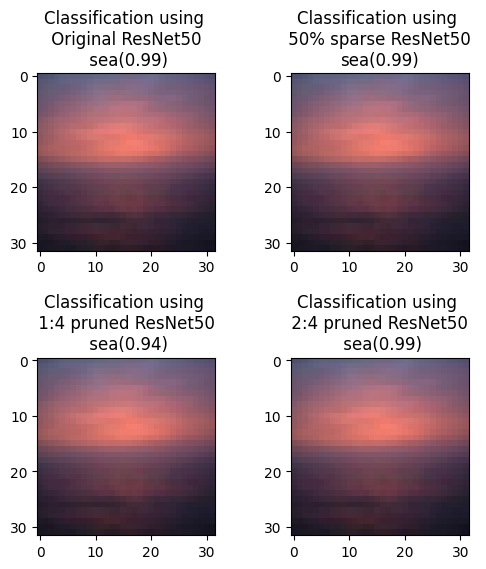

In [30]:
fig, axes = plt.subplots(2, 2, figsize = (6, 6))
# original_img = image.permute(1, 2, 0)
plt.subplots_adjust(hspace=0.6)
axes[0, 0].imshow(image)
axes[0, 0].set_title(f"Classification using \n Original ResNet50 \n {test_dataset_c100.classes[output_class_orig]}({output_class_orig_probs[0, output_class_orig].item():.2f})")


axes[0, 1].imshow(image)
axes[0, 1].set_title(f"Classification using \n 50% sparse ResNet50 \n{test_dataset_c100.classes[output_class_50_c100]}({output_class_50_probs[0, output_class_50_c100].item():.2f})")

axes[1, 0].imshow(image)
axes[1, 0].set_title(f"Classification using \n 1:4 pruned ResNet50 \n {test_dataset_c100.classes[output_class_1_4]}({output_class_1_4_probs[0, output_class_1_4].item():.2f})")


axes[1, 1].imshow(image)
axes[1, 1].set_title(f"Classification using \n 2:4 pruned ResNet50 \n {test_dataset_c100.classes[output_class_2_4]}({output_class_2_4_probs[0, output_class_2_4].item():.2f})")
